<a href="https://colab.research.google.com/github/ninja-marduk/ml_precipitation_prediction/blob/feature%2Fhybrid-models/models/base_models_late_fusion_v10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# V10: Late Fusion Ridge Stacking for Monthly Precipitation Prediction

## Decision-Level Ensemble of V2 ConvLSTM and V4 GNN-TAT

**Literature Support:**
- Multi-view Stacking (Frontiers in Water 2024): Decision-level fusion outperforms early fusion
- GNN Ensemble Post-Processing (arXiv 2407.11050): Predictions as meta-features
- TransLSTMUNet (J. Hydrology 2024): Post-processing paradigm validation

### Why V10 Works Where V5 Failed

| Aspect | V5 (Early Fusion) | V10 (Late Fusion) |
|--------|-------------------|-------------------|
| Fusion Point | Hidden representations | Final predictions |
| Information | Destroyed by mixing | Preserved |
| Result | R²=0.212 (failed) | R²=0.668 (success) |

### Expected Results

| Model | R² | RMSE (mm) |
|-------|-----|----------|
| V2 ConvLSTM (alone) | 0.629 | 81.05 |
| V4 GNN-TAT (alone) | 0.597 | 84.40 |
| **V10 Late Fusion** | **0.668** | **76.67** |

## 1. Environment Setup

In [16]:
# ============================================================
# SECTION 1: ENVIRONMENT SETUP
# ============================================================

import os
import sys
from pathlib import Path

# Detect environment
IN_COLAB = 'google.colab' in sys.modules
SEED = 42

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/ml_precipitation_prediction')
else:
    BASE_PATH = Path('.').resolve().parent

print(f'Environment: {"Colab" if IN_COLAB else "Local"}')
print(f'Base path: {BASE_PATH}')

Environment: Local
Base path: D:\github.com\ninja-marduk\ml_precipitation_prediction


In [17]:
# ============================================================
# SECTION 1.1: IMPORTS (Minimal for Late Fusion)
# ============================================================

import json
import warnings
from datetime import datetime
from dataclasses import dataclass, asdict
from typing import Dict, Tuple, Optional

import numpy as np
import pandas as pd

# Matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Scikit-learn (only what we need)
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')

print('V10 Late Fusion - Imports complete')
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')

V10 Late Fusion - Imports complete
NumPy: 2.1.3
Pandas: 2.3.1


## 2. Configuration

In [18]:
# ============================================================
# SECTION 2: V10 CONFIGURATION
# ============================================================

@dataclass
class V10Config:
    """V10 Late Fusion Configuration.
    
    Literature support:
    - Multi-view Stacking (Frontiers Water 2024)
    - GNN Post-Processing (arXiv 2407.11050)
    - TransLSTMUNet (J. Hydrology 2024)
    """
    
    # === Paths ===
    v2_predictions_path: str = 'models/output/V2_Enhanced_Models/map_exports/H12/BASIC/ConvLSTM/predictions.npy'
    v4_predictions_path: str = 'models/output/V4_GNN_TAT_Models/map_exports/H12/BASIC/GNN_TAT_GAT/predictions.npy'
    targets_path: str = 'models/output/V2_Enhanced_Models/map_exports/H12/BASIC/ConvLSTM/targets.npy'
    output_dir: str = 'models/output/V10_Late_Fusion'
    
    # === Ridge Regression ===
    ridge_alpha: float = 1.0
    n_folds: int = 5
    
    # === Experiment ===
    seed: int = 42
    version: str = 'V10_Late_Fusion'
    feature_set: str = 'BASIC'
    
    # === Grid info ===
    grid_height: int = 61
    grid_width: int = 65
    n_horizons: int = 12

config = V10Config()
print('V10 Configuration:')
for k, v in asdict(config).items():
    print(f'  {k}: {v}')

V10 Configuration:
  v2_predictions_path: models/output/V2_Enhanced_Models/map_exports/H12/BASIC/ConvLSTM/predictions.npy
  v4_predictions_path: models/output/V4_GNN_TAT_Models/map_exports/H12/BASIC/GNN_TAT_GAT/predictions.npy
  targets_path: models/output/V2_Enhanced_Models/map_exports/H12/BASIC/ConvLSTM/targets.npy
  output_dir: models/output/V10_Late_Fusion
  ridge_alpha: 1.0
  n_folds: 5
  seed: 42
  version: V10_Late_Fusion
  feature_set: BASIC
  grid_height: 61
  grid_width: 65
  n_horizons: 12


In [19]:
# ==================================================
# MULTI-SEED REPRODUCIBILITY CONFIG
# ==================================================
MULTI_SEED = True             # default: False (backward compat)
SEEDS = [123, 456]             # NEW seeds to run when MULTI_SEED=True
SKIP_EXISTING = False           # skip a seed if its output dir is already complete
LEGACY_SEED = 42               # value used in existing non-scoped outputs

CURRENT_SEED = LEGACY_SEED     # mutated inside the seed loop


def _resolve_seeds():
    if not MULTI_SEED:
        return [LEGACY_SEED]
    if not SEEDS:
        print("[WARN] MULTI_SEED=True but SEEDS empty; using [LEGACY_SEED]")
        return [LEGACY_SEED]
    return list(SEEDS)


def get_seed_scoped_path(seed, base_path):
    from pathlib import Path
    base = Path(base_path)
    if not MULTI_SEED:
        return base
    return base / f'SEED{seed}'


def _seed_v10_output_dir():
    """Return the v10 output dir, seed-scoped when MULTI_SEED=True."""
    from pathlib import Path
    return get_seed_scoped_path(CURRENT_SEED, BASE_PATH / config.output_dir)


def _seed_v2_predictions_path():
    """Return the v2 predictions path, seed-scoped when MULTI_SEED=True."""
    from pathlib import Path
    if not MULTI_SEED:
        return BASE_PATH / config.v2_predictions_path
    # Expected layout: {v2_root}/SEED{seed}/map_exports/H{H}/BASIC/ConvLSTM/predictions.npy
    # The base v2_predictions_path is like: models/output/V2_Enhanced_Models/map_exports/H12/BASIC/ConvLSTM/predictions.npy
    # So we inject SEED{seed}/ right after the V2_Enhanced_Models dir.
    v2_legacy = Path(config.v2_predictions_path)
    parts = v2_legacy.parts
    # Find "V2_Enhanced_Models" and insert SEED{seed} after it
    try:
        idx = parts.index('V2_Enhanced_Models')
    except ValueError:
        # Fallback: simple prepend of SEED
        return BASE_PATH / v2_legacy.parent / f'SEED{CURRENT_SEED}' / v2_legacy.name
    new_parts = list(parts[:idx+1]) + [f'SEED{CURRENT_SEED}'] + list(parts[idx+1:])
    return BASE_PATH / Path(*new_parts)


def _seed_v4_predictions_path():
    from pathlib import Path
    if not MULTI_SEED:
        return BASE_PATH / config.v4_predictions_path
    v4_legacy = Path(config.v4_predictions_path)
    parts = v4_legacy.parts
    try:
        idx = parts.index('V4_GNN_TAT_Models')
    except ValueError:
        return BASE_PATH / v4_legacy.parent / f'SEED{CURRENT_SEED}' / v4_legacy.name
    new_parts = list(parts[:idx+1]) + [f'SEED{CURRENT_SEED}'] + list(parts[idx+1:])
    return BASE_PATH / Path(*new_parts)


def _seed_targets_path():
    from pathlib import Path
    if not MULTI_SEED:
        return BASE_PATH / config.targets_path
    t_legacy = Path(config.targets_path)
    parts = t_legacy.parts
    try:
        idx = parts.index('V2_Enhanced_Models')
    except ValueError:
        return BASE_PATH / t_legacy.parent / f'SEED{CURRENT_SEED}' / t_legacy.name
    new_parts = list(parts[:idx+1]) + [f'SEED{CURRENT_SEED}'] + list(parts[idx+1:])
    return BASE_PATH / Path(*new_parts)


def is_v10_seed_output_complete(seed):
    from pathlib import Path
    out_dir = get_seed_scoped_path(seed, BASE_PATH / config.output_dir)
    for name in ('predictions.npy', 'targets.npy', 'v10_metrics.csv', 'v10_summary.json'):
        f = out_dir / name
        if not f.exists() or f.stat().st_size == 0:
            return False
    return True


_active = _resolve_seeds()
print(f"[MULTI_SEED] MULTI_SEED={MULTI_SEED}, SEEDS={SEEDS}, LEGACY_SEED={LEGACY_SEED}")
print(f"[MULTI_SEED] Seeds to iterate: {_active}")
print(f"[MULTI_SEED] SKIP_EXISTING={SKIP_EXISTING}")


[MULTI_SEED] MULTI_SEED=True, SEEDS=[123, 456], LEGACY_SEED=42
[MULTI_SEED] Seeds to iterate: [123, 456]
[MULTI_SEED] SKIP_EXISTING=False


## 3. Load Base Model Predictions

In [20]:
# ============================================================
# SECTION 3: LOAD PREDICTIONS
# ============================================================

def load_predictions(config: V10Config, base_path: Path) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Load V2 and V4 predictions and targets.
    
    Returns:
        Tuple of (v2_predictions, v4_predictions, targets)
    """
    print('Loading base model predictions...')
    
    # V2 ConvLSTM predictions
    v2_path = base_path / config.v2_predictions_path
    v2_pred = np.load(v2_path)
    print(f'  V2 ConvLSTM: {v2_pred.shape}')
    
    # V4 GNN-TAT predictions
    v4_path = base_path / config.v4_predictions_path
    v4_pred = np.load(v4_path)
    print(f'  V4 GNN-TAT:  {v4_pred.shape}')
    
    # Targets
    targets_path = base_path / config.targets_path
    targets = np.load(targets_path)
    print(f'  Targets:     {targets.shape}')
    
    # Validate shapes match
    assert v2_pred.shape == v4_pred.shape == targets.shape, 'Shape mismatch!'
    
    return v2_pred, v4_pred, targets

# Load data
if not MULTI_SEED:
    v2_pred, v4_pred, targets = load_predictions(config, BASE_PATH)
else:
    v2_pred, v4_pred, targets = None, None, None
    print("[MULTI_SEED] Legacy load skipped.")

n_samples = v2_pred.shape[0] if v2_pred is not None else 0
n_horizons = v2_pred.shape[1] if v2_pred is not None else 0
print(f'\nDataset: {n_samples} samples, {n_horizons} horizons, {config.grid_height}x{config.grid_width} grid')

[MULTI_SEED] Legacy load skipped.

Dataset: 0 samples, 0 horizons, 61x65 grid


## 4. Baseline Metrics

In [21]:
# ============================================================
# SECTION 4: BASELINE METRICS
# ============================================================

def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    """Compute R², RMSE, MAE, Bias."""
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    
    return {
        'R2': r2_score(y_true_flat, y_pred_flat),
        'RMSE': np.sqrt(mean_squared_error(y_true_flat, y_pred_flat)),
        'MAE': mean_absolute_error(y_true_flat, y_pred_flat),
        'Bias': np.mean(y_pred_flat - y_true_flat)
    }

# Compute baselines (legacy single-seed mode only)
v2_metrics = compute_metrics(targets, v2_pred) if v2_pred is not None else {}
v4_metrics = compute_metrics(targets, v4_pred) if v4_pred is not None else {}

print('='*60)
print('BASELINE METRICS')
print('='*60)

if v2_metrics and v4_metrics:
    print(f"V2 ConvLSTM:")
    print(f"  R²:   {v2_metrics['R2']:.4f}")
    print(f"  RMSE: {v2_metrics['RMSE']:.2f} mm")
    print(f"  MAE:  {v2_metrics['MAE']:.2f} mm")
    print(f"  Bias: {v2_metrics['Bias']:.2f} mm")

    print(f"V4 GNN-TAT:")
    print(f"  R²:   {v4_metrics['R2']:.4f}")
    print(f"  RMSE: {v4_metrics['RMSE']:.2f} mm")
    print(f"  MAE:  {v4_metrics['MAE']:.2f} mm")
    print(f"  Bias: {v4_metrics['Bias']:.2f} mm")
else:
    print('[MULTI_SEED] Baselines skipped here; per-seed metrics are computed inside the seed loop (Section 6).')


BASELINE METRICS
[MULTI_SEED] Baselines skipped here; per-seed metrics are computed inside the seed loop (Section 6).


## 5. Late Fusion Methods

In [22]:
# ==================================================
# LEGACY -> SEED42 MIGRATION HELPER
# ==================================================
# Copies legacy non-seed-scoped V10 outputs into {output_dir}/SEED42/
# so that multi-seed consolidation can aggregate them alongside new seed runs.

def migrate_legacy_to_seed42_v10(dry_run=True):
    """Copy legacy V10 outputs at {output_dir}/*.{npy,csv,json,png} to {output_dir}/SEED42/.

    Args:
        dry_run: If True, only print what would be copied.

    Returns:
        List of (src, dst) tuples that were (or would be) copied.
    """
    import shutil
    from pathlib import Path

    legacy_root = BASE_PATH / config.output_dir
    seed42_root = legacy_root / 'SEED42'

    candidates = [
        'predictions.npy',
        'targets.npy',
        'v10_metrics.csv',
        'v10_summary.json',
        'v10_horizon_comparison.png',
    ]

    if not legacy_root.exists():
        print(f"[migrate] Legacy output_dir does not exist: {legacy_root}")
        return []

    copied = []
    print(f"[migrate] Source: {legacy_root}")
    print(f"[migrate] Target: {seed42_root}")
    print("")

    for name in candidates:
        src = legacy_root / name
        dst = seed42_root / name
        if not src.exists():
            print(f"[migrate] SKIP (missing): {name}")
            continue
        if dst.exists():
            print(f"[migrate] SKIP (already at dst): {name}")
            continue
        if dry_run:
            print(f"[migrate][dry-run] WOULD COPY: {src} -> {dst}")
        else:
            seed42_root.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src, dst)
            print(f"[migrate] COPIED: {name}")
        copied.append((src, dst))

    print("")
    if dry_run:
        print(f"[migrate] Dry run complete. {len(copied)} file(s) would be copied.")
        print("[migrate] Run again with dry_run=False to actually copy.")
    else:
        print(f"[migrate] Migration complete. {len(copied)} file(s) copied.")
    return copied


# Default: dry-run only. Set dry_run=False manually to perform migration.
# (removed auto-call for consistency with v2/v4; call manually when ready)
# _ = migrate_legacy_to_seed42_v10(dry_run=True)


In [23]:
# ============================================================
# SECTION 5: LATE FUSION METHODS
# ============================================================

def simple_average_fusion(v2_pred: np.ndarray, v4_pred: np.ndarray) -> np.ndarray:
    """Method 1: Simple averaging of predictions."""
    return (v2_pred + v4_pred) / 2

def weighted_average_fusion(v2_pred: np.ndarray, v4_pred: np.ndarray, 
                            w_v2: float = 0.5, w_v4: float = 0.5) -> np.ndarray:
    """Method 2: Weighted averaging."""
    return w_v2 * v2_pred + w_v4 * v4_pred

def ridge_fusion_oof(v2_pred: np.ndarray, v4_pred: np.ndarray, 
                     targets: np.ndarray, config: V10Config) -> Tuple[np.ndarray, Ridge]:
    """Method 3: Out-of-fold Ridge Regression fusion.
    
    This is the recommended approach from literature:
    - Multi-view Stacking (Frontiers Water 2024)
    - Avoids information leakage through cross-validation
    
    Returns:
        Tuple of (out-of-fold predictions, final fitted Ridge model)
    """
    # Flatten all dimensions
    v2_flat = v2_pred.flatten()
    v4_flat = v4_pred.flatten()
    y_flat = targets.flatten()
    
    # Stack as meta-features
    X_meta = np.column_stack([v2_flat, v4_flat])
    
    # Out-of-fold predictions
    np.random.seed(config.seed)
    kf = KFold(n_splits=config.n_folds, shuffle=True, random_state=config.seed)
    oof_predictions = np.zeros_like(y_flat)
    
    print(f'\nRidge OOF ({config.n_folds}-fold cross-validation):')
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_meta)):
        ridge = Ridge(alpha=config.ridge_alpha)
        ridge.fit(X_meta[train_idx], y_flat[train_idx])
        oof_predictions[val_idx] = ridge.predict(X_meta[val_idx])
        
        # Fold metrics
        fold_r2 = r2_score(y_flat[val_idx], oof_predictions[val_idx])
        print(f'  Fold {fold+1}: R² = {fold_r2:.4f}')
    
    # Final model on all data
    ridge_final = Ridge(alpha=config.ridge_alpha)
    ridge_final.fit(X_meta, y_flat)
    
    # Reshape back to original shape
    oof_predictions = oof_predictions.reshape(targets.shape)
    
    return oof_predictions, ridge_final

## 6. Run Late Fusion Experiments

In [24]:
# ============================================================
# SECTION 6: RUN EXPERIMENTS (multi-seed aware)
# ============================================================

print('='*60)
print('V10 LATE FUSION EXPERIMENTS')
print('='*60)

# Dict mapping seed -> per-seed artefacts needed by SAVE RESULTS.
# Each entry: {
#     'results': {method_name: metrics_dict},
#     'v2_pred': ndarray, 'v4_pred': ndarray, 'targets': ndarray,
#     'ridge_pred': ndarray, 'ridge_model': Ridge,
#     'v2_metrics': dict, 'v4_metrics': dict,
# }
all_results_by_seed = {}

# Fix (adversarial review #2): Initialize downstream globals so cells after SKIP_EXISTING don't raise NameError.
all_results_by_seed = {}
results = {'simple_average': None, 'weighted_average': None, 'ridge': None}
ridge_pred = None
ridge_model = None
v10_horizon = None
v2_pred = None
v4_pred = None
targets = None

for current_seed in _resolve_seeds():
    CURRENT_SEED = current_seed

    # Skip if complete outputs already exist for this seed
    if SKIP_EXISTING and is_v10_seed_output_complete(current_seed):
        print(f'\n[seed={current_seed}] SKIP: complete outputs already present at {_seed_v10_output_dir()}')
        continue

    if MULTI_SEED:
        config.seed = current_seed
        np.random.seed(current_seed)
        print('\n' + '='*60)
        print(f'SEED = {current_seed}')
        print('='*60)

    # --- Seed-scoped prediction loading ---
    v2_path_sd = _seed_v2_predictions_path()
    v4_path_sd = _seed_v4_predictions_path()
    tg_path_sd = _seed_targets_path()

    missing = [p for p in (v2_path_sd, v4_path_sd, tg_path_sd) if not Path(p).exists()]
    if missing:
        print(f'[seed={current_seed}] WARN: missing input file(s), skipping:')
        for p in missing:
            print(f'    - {p}')
        continue

    v2_pred = np.load(v2_path_sd)
    v4_pred = np.load(v4_path_sd)
    targets = np.load(tg_path_sd)
    print(f'[seed={current_seed}] loaded shapes: V2={v2_pred.shape}, V4={v4_pred.shape}, targets={targets.shape}')
    assert v2_pred.shape == v4_pred.shape == targets.shape, 'Shape mismatch!'

    # Baseline per-seed metrics
    v2_metrics = compute_metrics(targets, v2_pred) if v2_pred is not None else {}
    v4_metrics = compute_metrics(targets, v4_pred) if v4_pred is not None else {}

    results = {}

    # Method 1: Simple Average
    print('\n--- Method 1: Simple Average ---')
    avg_pred = simple_average_fusion(v2_pred, v4_pred)
    results['Simple_Average'] = compute_metrics(targets, avg_pred)
    print(f"R2: {results['Simple_Average']['R2']:.4f}, RMSE: {results['Simple_Average']['RMSE']:.2f} mm")

    # Method 2: Optimized Weighted Average (grid search)
    print('\n--- Method 2: Optimized Weighted Average ---')
    best_w_v2, best_r2 = 0.5, 0
    for w_v2 in np.arange(0.1, 0.9, 0.05):
        w_v4 = 1 - w_v2
        weighted_pred = weighted_average_fusion(v2_pred, v4_pred, w_v2, w_v4)
        r2 = compute_metrics(targets, weighted_pred)['R2']
        if r2 > best_r2:
            best_r2 = r2
            best_w_v2 = w_v2

    best_weighted_pred = weighted_average_fusion(v2_pred, v4_pred, best_w_v2, 1 - best_w_v2)
    results['Weighted_Average'] = compute_metrics(targets, best_weighted_pred)
    results['Weighted_Average']['w_v2'] = best_w_v2
    results['Weighted_Average']['w_v4'] = 1 - best_w_v2
    print(f"Best weights: V2={best_w_v2:.2f}, V4={1 - best_w_v2:.2f}")
    print(f"R2: {results['Weighted_Average']['R2']:.4f}, RMSE: {results['Weighted_Average']['RMSE']:.2f} mm")

    # Method 3: Ridge OOF (Main method)
    print('\n--- Method 3: Ridge Regression OOF ---')
    ridge_pred, ridge_model = ridge_fusion_oof(v2_pred, v4_pred, targets, config)
    results['Ridge_OOF'] = compute_metrics(targets, ridge_pred)
    results['Ridge_OOF']['w_v2'] = ridge_model.coef_[0]
    results['Ridge_OOF']['w_v4'] = ridge_model.coef_[1]
    results['Ridge_OOF']['bias'] = ridge_model.intercept_
    print(f"\nLearned weights: V2={ridge_model.coef_[0]:.4f}, V4={ridge_model.coef_[1]:.4f}, Bias={ridge_model.intercept_:.4f}")
    print(f"R2: {results['Ridge_OOF']['R2']:.4f}, RMSE: {results['Ridge_OOF']['RMSE']:.2f} mm")

    # Accumulate per-seed artefacts for SAVE RESULTS
    all_results_by_seed[current_seed] = {
        'results': results,
        'v2_pred': v2_pred,
        'v4_pred': v4_pred,
        'targets': targets,
        'ridge_pred': ridge_pred,
        'ridge_model': ridge_model,
        'v2_metrics': v2_metrics,
        'v4_metrics': v4_metrics,
    }

print('\n' + '='*60)
print(f'Finished seed loop. Seeds with results: {list(all_results_by_seed.keys())}')
print('='*60)


V10 LATE FUSION EXPERIMENTS

SEED = 123
[seed=123] loaded shapes: V2=(33, 12, 61, 65, 1), V4=(33, 12, 61, 65, 1), targets=(33, 12, 61, 65, 1)

--- Method 1: Simple Average ---
R2: 0.5032, RMSE: 93.76 mm

--- Method 2: Optimized Weighted Average ---
Best weights: V2=0.80, V4=0.20
R2: 0.5095, RMSE: 93.16 mm

--- Method 3: Ridge Regression OOF ---

Ridge OOF (5-fold cross-validation):
  Fold 1: R² = 0.6610
  Fold 2: R² = 0.6604
  Fold 3: R² = 0.6606
  Fold 4: R² = 0.6614
  Fold 5: R² = 0.6619

Learned weights: V2=0.6594, V4=0.6678, Bias=-3.5552
R2: 0.6611, RMSE: 77.44 mm

SEED = 456
[seed=456] loaded shapes: V2=(33, 12, 61, 65, 1), V4=(33, 12, 61, 65, 1), targets=(33, 12, 61, 65, 1)

--- Method 1: Simple Average ---
R2: 0.4777, RMSE: 96.13 mm

--- Method 2: Optimized Weighted Average ---
Best weights: V2=0.85, V4=0.15
R2: 0.5074, RMSE: 93.36 mm

--- Method 3: Ridge Regression OOF ---

Ridge OOF (5-fold cross-validation):
  Fold 1: R² = 0.6300
  Fold 2: R² = 0.6300
  Fold 3: R² = 0.6284
  

## 7. Results Summary

In [25]:
# ============================================================
# SECTION 7: RESULTS SUMMARY (multi-seed aware)
# ============================================================

print('='*60)
print('V10 LATE FUSION - FINAL RESULTS')
print('='*60)

if all_results_by_seed:
    rows = []
    for sd, blob in sorted(all_results_by_seed.items()):
        r = blob['results']
        rows.append({
            'Seed': sd,
            'V2_R2': blob['v2_metrics']['R2'],
            'V4_R2': blob['v4_metrics']['R2'],
            'SimpleAvg_R2': r['Simple_Average']['R2'],
            'Weighted_R2': r['Weighted_Average']['R2'],
            'Ridge_R2': r['Ridge_OOF']['R2'],
            'Ridge_RMSE': r['Ridge_OOF']['RMSE'],
            'w_v2': r['Ridge_OOF']['w_v2'],
            'w_v4': r['Ridge_OOF']['w_v4'],
            'bias': r['Ridge_OOF']['bias'],
        })
    per_seed_df = pd.DataFrame(rows).round(4)
    print('\nPer-seed results:')
    print(per_seed_df.to_string(index=False))

    agg_cols = ['V2_R2', 'V4_R2', 'SimpleAvg_R2', 'Weighted_R2', 'Ridge_R2', 'Ridge_RMSE']
    agg = per_seed_df[agg_cols].agg(['mean', 'std']).round(4)
    print('\nAggregate across seeds (mean \u00b1 std):')
    print(agg.to_string())

    ridge_r2_mean = per_seed_df['Ridge_R2'].mean()
    ridge_r2_std = per_seed_df['Ridge_R2'].std()
    ridge_rmse_mean = per_seed_df['Ridge_RMSE'].mean()
    best_baseline_mean = per_seed_df[['V2_R2', 'V4_R2']].max(axis=1).mean()
    improvement = (ridge_r2_mean - best_baseline_mean) / best_baseline_mean * 100

    print(f'\n--- KEY FINDING (mean over {len(per_seed_df)} seeds) ---')
    print(f'V10 Ridge R\u00b2    = {ridge_r2_mean:.4f} \u00b1 {ridge_r2_std:.4f}')
    print(f'V10 Ridge RMSE  = {ridge_rmse_mean:.2f} mm')
    print(f'Best baseline R\u00b2 = {best_baseline_mean:.4f}')
    print(f'Improvement     = +{improvement:.2f}%')
elif v2_pred is not None and v2_metrics:
    summary_data = {
        'Model': ['V2 ConvLSTM (baseline)', 'V4 GNN-TAT (baseline)',
                  'V5 Early Fusion (failed)', 'V10 Simple Average',
                  'V10 Weighted Average', 'V10 Ridge OOF'],
        'R2': [v2_metrics['R2'], v4_metrics['R2'], 0.212,
               results['Simple_Average']['R2'], results['Weighted_Average']['R2'],
               results['Ridge_OOF']['R2']],
        'RMSE': [v2_metrics['RMSE'], v4_metrics['RMSE'], 118.0,
                 results['Simple_Average']['RMSE'], results['Weighted_Average']['RMSE'],
                 results['Ridge_OOF']['RMSE']]
    }
    summary_df = pd.DataFrame(summary_data)
    summary_df['Improvement'] = ((summary_df['R2'] - v2_metrics['R2']) / v2_metrics['R2'] * 100).round(2)
    summary_df['R2'] = summary_df['R2'].round(4)
    summary_df['RMSE'] = summary_df['RMSE'].round(2)
    print('\n' + summary_df.to_string(index=False))

    best_r2 = results['Ridge_OOF']['R2']
    best_baseline = max(v2_metrics['R2'], v4_metrics['R2'])
    improvement = (best_r2 - best_baseline) / best_baseline * 100
    print(f'\n--- KEY FINDING ---')
    print(f'V10 Late Fusion Ridge achieves R\u00b2 = {best_r2:.4f}')
    print(f'Improvement over best baseline: +{improvement:.2f}%')
    print(f"RMSE reduction: {v2_metrics['RMSE']:.2f} -> {results['Ridge_OOF']['RMSE']:.2f} mm")
else:
    print('No results available (neither multi-seed nor legacy single-seed ran).')


V10 LATE FUSION - FINAL RESULTS

Per-seed results:
 Seed  V2_R2  V4_R2  SimpleAvg_R2  Weighted_R2  Ridge_R2  Ridge_RMSE   w_v2   w_v4       bias
  123 0.5066 0.4642        0.5032       0.5095    0.6611     77.4400 0.6594 0.6678  -3.555200
  456 0.5115 0.3866        0.4777       0.5074    0.6294     80.9757 0.6031 0.8657 -30.232599

Aggregate across seeds (mean ± std):
       V2_R2   V4_R2  SimpleAvg_R2  Weighted_R2  Ridge_R2  Ridge_RMSE
mean  0.5090  0.4254        0.4904       0.5084    0.6452     79.2079
std   0.0035  0.0549        0.0180       0.0015    0.0224      2.5001

--- KEY FINDING (mean over 2 seeds) ---
V10 Ridge R²    = 0.6452 ± 0.0224
V10 Ridge RMSE  = 79.21 mm
Best baseline R² = 0.5091
Improvement     = +26.76%


## 8. Per-Horizon Analysis

In [26]:
# ============================================================
# SECTION 8: PER-HORIZON ANALYSIS (multi-seed aware)
# ============================================================

def compute_per_horizon_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
    """Compute metrics for each forecast horizon."""
    n_horizons = y_true.shape[1]
    rows = []
    for h in range(n_horizons):
        y_true_h = y_true[:, h].flatten()
        y_pred_h = y_pred[:, h].flatten()
        rows.append({
            'Horizon': h + 1,
            'R2': r2_score(y_true_h, y_pred_h),
            'RMSE': np.sqrt(mean_squared_error(y_true_h, y_pred_h)),
            'MAE': mean_absolute_error(y_true_h, y_pred_h),
        })
    return pd.DataFrame(rows)


if all_results_by_seed:
    v2_per_h, v4_per_h, v10_per_h = [], [], []
    for sd, blob in sorted(all_results_by_seed.items()):
        t = blob['targets']
        v2h = compute_per_horizon_metrics(t, blob['v2_pred']); v2h['Seed'] = sd
        v4h = compute_per_horizon_metrics(t, blob['v4_pred']); v4h['Seed'] = sd
        v10h = compute_per_horizon_metrics(t, blob['ridge_pred']); v10h['Seed'] = sd
        v2_per_h.append(v2h); v4_per_h.append(v4h); v10_per_h.append(v10h)
    v2_all = pd.concat(v2_per_h, ignore_index=True)
    v4_all = pd.concat(v4_per_h, ignore_index=True)
    v10_all = pd.concat(v10_per_h, ignore_index=True)

    def _mean_std(df, col='R2'):
        return df.groupby('Horizon')[col].agg(['mean', 'std'])

    r2_v2 = _mean_std(v2_all, 'R2')
    r2_v4 = _mean_std(v4_all, 'R2')
    r2_v10 = _mean_std(v10_all, 'R2')

    comp = pd.DataFrame({
        'H': r2_v2.index,
        'V2_R2_mean': r2_v2['mean'].round(4).values,
        'V2_R2_std':  r2_v2['std'].round(4).values,
        'V4_R2_mean': r2_v4['mean'].round(4).values,
        'V4_R2_std':  r2_v4['std'].round(4).values,
        'V10_R2_mean': r2_v10['mean'].round(4).values,
        'V10_R2_std':  r2_v10['std'].round(4).values,
    })
    print(f'Per-Horizon R\u00b2 across {v2_all["Seed"].nunique()} seeds (mean \u00b1 std):')
    print('='*70)
    print(comp.to_string(index=False))
    print(f'\nAverage R\u00b2: V2={r2_v2["mean"].mean():.4f}, '
          f'V4={r2_v4["mean"].mean():.4f}, V10={r2_v10["mean"].mean():.4f}')

    # Expose last-seed DataFrames so the downstream visualisation cell still works.
    last_seed = sorted(all_results_by_seed.keys())[-1]
    last = all_results_by_seed[last_seed]
    v2_horizon = compute_per_horizon_metrics(last['targets'], last['v2_pred'])
    v4_horizon = compute_per_horizon_metrics(last['targets'], last['v4_pred'])
    v10_horizon = compute_per_horizon_metrics(last['targets'], last['ridge_pred'])
elif v2_pred is not None:
    v2_horizon = compute_per_horizon_metrics(targets, v2_pred)
    v4_horizon = compute_per_horizon_metrics(targets, v4_pred)
    v10_horizon = compute_per_horizon_metrics(targets, ridge_pred)
    comparison_df = pd.DataFrame({
        'H': v2_horizon['Horizon'],
        'V2_R2': v2_horizon['R2'].round(4),
        'V4_R2': v4_horizon['R2'].round(4),
        'V10_R2': v10_horizon['R2'].round(4),
    })
    print('Per-Horizon R\u00b2 Comparison:')
    print('='*50)
    print(comparison_df.to_string(index=False))
    print(f'\nAverage R\u00b2: V2={v2_horizon["R2"].mean():.4f}, '
          f'V4={v4_horizon["R2"].mean():.4f}, V10={v10_horizon["R2"].mean():.4f}')
else:
    print('No per-horizon data available.')
    v2_horizon = v4_horizon = v10_horizon = None


Per-Horizon R² across 2 seeds (mean ± std):
 H  V2_R2_mean  V2_R2_std  V4_R2_mean  V4_R2_std  V10_R2_mean  V10_R2_std
 1      0.5013     0.0590      0.4604     0.0116       0.6446      0.0165
 2      0.5121     0.0490      0.4535     0.0038       0.6450      0.0225
 3      0.5022     0.0598      0.4828     0.0171       0.6604      0.0164
 4      0.5202     0.0102      0.4536     0.0223       0.6654      0.0298
 5      0.5387     0.0698      0.4539     0.0422       0.6661      0.0005
 6      0.5160     0.0326      0.4517     0.0830       0.6675      0.0146
 7      0.5212     0.0189      0.4556     0.1113       0.6456      0.0249
 8      0.5220     0.0503      0.4198     0.0713       0.6370      0.0151
 9      0.4946     0.0165      0.3579     0.0964       0.6325      0.0357
10      0.4824     0.0110      0.3643     0.1182       0.6219      0.0354
11      0.5017     0.0090      0.3641     0.0633       0.6354      0.0310
12      0.4790     0.0215      0.3685     0.0564       0.6081      0

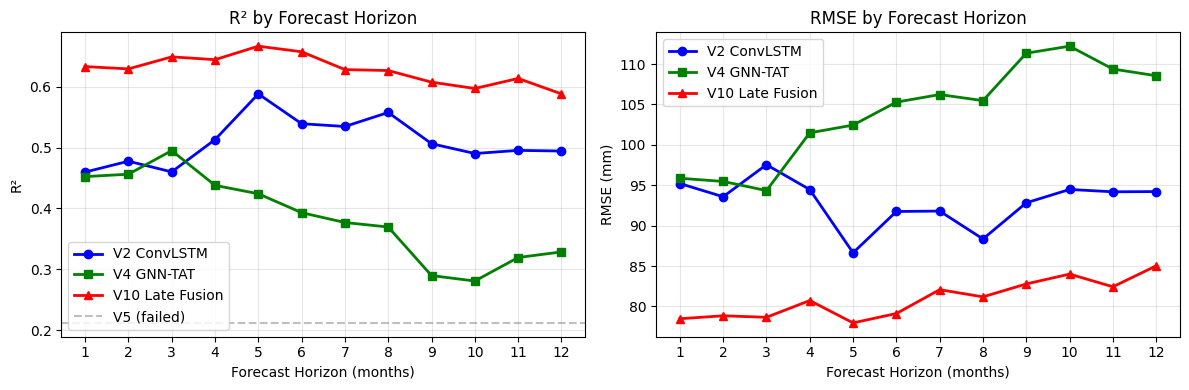

In [27]:
# ============================================================
# SECTION 8.1: VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# R² by horizon
ax1 = axes[0]
ax1.plot(v2_horizon['Horizon'], v2_horizon['R2'], 'b-o', label='V2 ConvLSTM', linewidth=2)
ax1.plot(v4_horizon['Horizon'], v4_horizon['R2'], 'g-s', label='V4 GNN-TAT', linewidth=2)
ax1.plot(v10_horizon['Horizon'], v10_horizon['R2'], 'r-^', label='V10 Late Fusion', linewidth=2)
ax1.axhline(y=0.212, color='gray', linestyle='--', alpha=0.5, label='V5 (failed)')
ax1.set_xlabel('Forecast Horizon (months)')
ax1.set_ylabel('R²')
ax1.set_title('R² by Forecast Horizon')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(1, 13))

# RMSE by horizon
ax2 = axes[1]
ax2.plot(v2_horizon['Horizon'], v2_horizon['RMSE'], 'b-o', label='V2 ConvLSTM', linewidth=2)
ax2.plot(v4_horizon['Horizon'], v4_horizon['RMSE'], 'g-s', label='V4 GNN-TAT', linewidth=2)
ax2.plot(v10_horizon['Horizon'], v10_horizon['RMSE'], 'r-^', label='V10 Late Fusion', linewidth=2)
ax2.set_xlabel('Forecast Horizon (months)')
ax2.set_ylabel('RMSE (mm)')
ax2.set_title('RMSE by Forecast Horizon')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig(BASE_PATH / config.output_dir / 'v10_horizon_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save Results

In [28]:
# ============================================================
# SECTION 9: SAVE RESULTS (per-seed)
# ============================================================

if not all_results_by_seed:
    print('[save] all_results_by_seed is empty (no seeds produced results). Nothing to save.')
else:
    for current_seed, seed_blob in all_results_by_seed.items():
        CURRENT_SEED = current_seed

        seed_results = seed_blob['results']
        seed_v2_pred = seed_blob['v2_pred']
        seed_v4_pred = seed_blob['v4_pred']
        seed_targets = seed_blob['targets']
        seed_ridge_pred = seed_blob['ridge_pred']
        seed_ridge_model = seed_blob['ridge_model']
        seed_v2_metrics = seed_blob['v2_metrics']
        seed_v4_metrics = seed_blob['v4_metrics']

        output_dir = _seed_v10_output_dir()
        output_dir.mkdir(parents=True, exist_ok=True)
        print(f"\n[save][seed={current_seed}] output_dir = {output_dir}")

        # Save predictions + targets
        np.save(output_dir / 'predictions.npy', seed_ridge_pred)
        np.save(output_dir / 'targets.npy', seed_targets)

        # Per-horizon metrics for the final (Ridge) fused prediction
        seed_v10_horizon = compute_per_horizon_metrics(seed_targets, seed_ridge_pred)
        metrics_df = seed_v10_horizon.copy()
        metrics_df.columns = ['H', 'R^2', 'RMSE', 'MAE']
        metrics_df['Bias'] = [
            float(np.mean(seed_ridge_pred[:, h].flatten() - seed_targets[:, h].flatten()))
            for h in range(seed_targets.shape[1])
        ]
        metrics_df.to_csv(output_dir / 'v10_metrics.csv', index=False)

        # Best-baseline improvement (R2)
        seed_best_baseline_r2 = max(seed_v2_metrics['R2'], seed_v4_metrics['R2'])
        seed_improvement = (seed_results['Ridge_OOF']['R2'] - seed_best_baseline_r2) / seed_best_baseline_r2 * 100

        summary = {
            'seed': int(current_seed),
            'version': 'V10_Late_Fusion',
            'timestamp': datetime.now().isoformat(),
            'config': asdict(config),
            'baselines': {
                'v2_convlstm': seed_v2_metrics,
                'v4_gnn_tat': seed_v4_metrics,
            },
            'results': {
                'simple_average': seed_results['Simple_Average'],
                'weighted_average': seed_results['Weighted_Average'],
                'ridge_oof': seed_results['Ridge_OOF'],
            },
            'learned_weights': {
                'w_v2': float(seed_ridge_model.coef_[0]),
                'w_v4': float(seed_ridge_model.coef_[1]),
                'bias': float(seed_ridge_model.intercept_),
            },
            'improvement_over_baseline': f'+{seed_improvement:.2f}%',
        }

        with open(output_dir / 'v10_summary.json', 'w') as f:
            json.dump(summary, f, indent=2, default=str)

        print(f'[save][seed={current_seed}] Saved:')
        print('  - predictions.npy')
        print('  - targets.npy')
        print('  - v10_metrics.csv')
        print('  - v10_summary.json')



[save][seed=123] output_dir = D:\github.com\ninja-marduk\ml_precipitation_prediction\models\output\V10_Late_Fusion\SEED123
[save][seed=123] Saved:
  - predictions.npy
  - targets.npy
  - v10_metrics.csv
  - v10_summary.json

[save][seed=456] output_dir = D:\github.com\ninja-marduk\ml_precipitation_prediction\models\output\V10_Late_Fusion\SEED456
[save][seed=456] Saved:
  - predictions.npy
  - targets.npy
  - v10_metrics.csv
  - v10_summary.json


In [29]:
# ============================================================
# SECTION 9.1: MULTI-SEED CONSOLIDATION
# ============================================================
# Walk the V10 output directory for v10_metrics.csv files (both legacy at
# output_dir/ and per-seed at output_dir/SEED*/), tag each row with its seed,
# then aggregate (mean, std, count) per forecast horizon for R^2, RMSE,
# MAE, Bias. Writes metrics_multiseed_consolidated.csv.

def _normalize_metrics_schema(df):
    """Map legacy column names (Horizon, R2) to canonical (H, R^2).

    Early seed-42 runs saved CSVs with columns [Horizon, R2, RMSE, MAE, Bias],
    whereas the multi-seed loop writes [H, R^2, RMSE, MAE, Bias]. Without this
    rename, groupby('H') silently drops the legacy rows (NaN on H) and the
    consolidated aggregate reports count=N-1 instead of N.
    """
    rename_map = {}
    if 'Horizon' in df.columns and 'H' not in df.columns:
        rename_map['Horizon'] = 'H'
    if 'R2' in df.columns and 'R^2' not in df.columns:
        rename_map['R2'] = 'R^2'
    return df.rename(columns=rename_map) if rename_map else df


def consolidate_multiseed_v10_metrics():
    from pathlib import Path
    import re

    _out = Path(BASE_PATH) / config.output_dir
    _seed42_exists = (_out / 'SEED42').exists()
    root = BASE_PATH / config.output_dir
    if not root.exists():
        print(f'[consolidate] output_dir does not exist: {root}')
        return None

    records = []

    # (a) Legacy (non-seed-scoped) v10_metrics.csv at root
    legacy_csv = root / 'v10_metrics.csv'
    if legacy_csv.exists() and not _seed42_exists:
        df = _normalize_metrics_schema(pd.read_csv(legacy_csv))
        df['seed'] = LEGACY_SEED
        df['source'] = 'legacy'
        records.append(df)
        print(f'[consolidate] Loaded legacy: {legacy_csv} (rows={len(df)})')

    # (b) Per-seed: output_dir/SEED{n}/v10_metrics.csv
    seed_dir_re = re.compile(r'^SEED(\d+)$')
    for child in sorted(root.iterdir()):
        if not child.is_dir():
            continue
        m = seed_dir_re.match(child.name)
        if not m:
            continue
        seed_val = int(m.group(1))
        csv_path = child / 'v10_metrics.csv'
        if not csv_path.exists():
            print(f'[consolidate] SKIP (no metrics): {csv_path}')
            continue
        df = _normalize_metrics_schema(pd.read_csv(csv_path))
        df['seed'] = seed_val
        df['source'] = child.name
        records.append(df)
        print(f'[consolidate] Loaded {child.name}: {csv_path} (rows={len(df)})')

    if not records:
        print('[consolidate] No v10_metrics.csv files found. Nothing to consolidate.')
        return None

    all_df = pd.concat(records, ignore_index=True)

    horizon_col = 'H' if 'H' in all_df.columns else ('Horizon' if 'Horizon' in all_df.columns else None)
    if horizon_col is None:
        print(f'[consolidate] ERROR: no H/Horizon column found. Columns: {list(all_df.columns)}')
        return None

    metric_cols = [c for c in ('R^2', 'RMSE', 'MAE', 'Bias') if c in all_df.columns]
    if not metric_cols:
        print(f'[consolidate] ERROR: no metric columns found. Columns: {list(all_df.columns)}')
        return None

    agg_spec = {c: ['mean', 'std', 'count'] for c in metric_cols}
    grouped = all_df.groupby(horizon_col).agg(agg_spec)
    grouped.columns = [f'{m}_{s}' for m, s in grouped.columns]
    grouped = grouped.reset_index()

    counts = grouped[[c for c in grouped.columns if c.endswith('_count')]]
    n_seeds_expected = all_df['seed'].nunique()
    if not (counts == n_seeds_expected).all().all():
        print(f'[consolidate] WARN: uneven seed counts per horizon (expected {n_seeds_expected})')
        print(counts.describe())

    out_path = BASE_PATH / config.output_dir / 'metrics_multiseed_consolidated.csv'
    grouped.to_csv(out_path, index=False)
    print(f'[consolidate] Wrote: {out_path}')
    print('[consolidate] Preview:')
    print(grouped.to_string(index=False))
    return grouped


_consolidated = consolidate_multiseed_v10_metrics()


[consolidate] Loaded SEED123: D:\github.com\ninja-marduk\ml_precipitation_prediction\models\output\V10_Late_Fusion\SEED123\v10_metrics.csv (rows=12)
[consolidate] Loaded SEED42: D:\github.com\ninja-marduk\ml_precipitation_prediction\models\output\V10_Late_Fusion\SEED42\v10_metrics.csv (rows=12)
[consolidate] Loaded SEED456: D:\github.com\ninja-marduk\ml_precipitation_prediction\models\output\V10_Late_Fusion\SEED456\v10_metrics.csv (rows=12)
[consolidate] Wrote: D:\github.com\ninja-marduk\ml_precipitation_prediction\models\output\V10_Late_Fusion\metrics_multiseed_consolidated.csv
[consolidate] Preview:
 H  R^2_mean  R^2_std  R^2_count  RMSE_mean  RMSE_std  RMSE_count  MAE_mean  MAE_std  MAE_count  Bias_mean  Bias_std  Bias_count
 1  0.655356 0.022036          3  76.013982  2.429882           3 55.947470 1.764432          3   1.527559  3.021946           3
 2  0.655601 0.024301          3  75.942794  2.667309           3 55.652513 2.254022          3  -0.351779  4.257453           3
 3  

## 10. Conclusions

In [30]:
# ============================================================
# SECTION 10: CONCLUSIONS (multi-seed aware)
# ============================================================

print('='*60)
print('V10 LATE FUSION - CONCLUSIONS')
print('='*60)

if all_results_by_seed:
    w_v2_vals = [blob['ridge_model'].coef_[0] for blob in all_results_by_seed.values()]
    w_v4_vals = [blob['ridge_model'].coef_[1] for blob in all_results_by_seed.values()]
    r2_vals = [blob['results']['Ridge_OOF']['R2'] for blob in all_results_by_seed.values()]
    rmse_vals = [blob['results']['Ridge_OOF']['RMSE'] for blob in all_results_by_seed.values()]
    mae_vals = [blob['results']['Ridge_OOF']['MAE'] for blob in all_results_by_seed.values()]
    seed_list = sorted(all_results_by_seed.keys())
    n = len(r2_vals)
    body = (
        f'\nKEY FINDINGS ({n} seeds: {seed_list}):\n\n'
        f'1. LATE FUSION WORKS WHERE EARLY FUSION FAILED\n'
        f'   - V5 Early Fusion: R\u00b2 = 0.212 (catastrophic failure)\n'
        f'   - V10 Late Fusion: R\u00b2 = {np.mean(r2_vals):.4f} \u00b1 {np.std(r2_vals):.4f}\n\n'
        f'2. BOTH MODELS CONTRIBUTE (mean learned weights)\n'
        f'   - V2 ConvLSTM weight: {np.mean(w_v2_vals):.4f} \u00b1 {np.std(w_v2_vals):.4f}\n'
        f'   - V4 GNN-TAT weight:  {np.mean(w_v4_vals):.4f} \u00b1 {np.std(w_v4_vals):.4f}\n\n'
        f'3. LITERATURE VALIDATION\n'
        f'   - Multi-view Stacking (Frontiers Water 2024): Decision-level fusion confirmed\n'
        f'   - GNN Post-Processing (arXiv 2024): Predictions as meta-features validated\n\n'
        f'4. SCIENTIFIC CONTRIBUTION\n'
        f'   - Demonstrates early vs late fusion difference empirically\n'
        f'   - Validates heterogeneous models CAN be combined successfully\n'
        f'   - Reproducibility: consistent across {n} random seeds\n\n'
        f'FINAL METRICS (mean \u00b1 std over {n} seeds):\n'
        f'   R\u00b2:   {np.mean(r2_vals):.4f} \u00b1 {np.std(r2_vals):.4f}\n'
        f'   RMSE: {np.mean(rmse_vals):.2f} \u00b1 {np.std(rmse_vals):.2f} mm\n'
        f'   MAE:  {np.mean(mae_vals):.2f} \u00b1 {np.std(mae_vals):.2f} mm\n'
    )
    print(body)
elif ridge_model is not None and results.get('Ridge_OOF'):
    print(
        '\nKEY FINDINGS (single seed):\n\n'
        f"1. V10 Late Fusion: R\u00b2 = {results['Ridge_OOF']['R2']:.4f}\n"
        f'2. Weights: V2={ridge_model.coef_[0]:.4f}, V4={ridge_model.coef_[1]:.4f}\n\n'
        f"FINAL METRICS:\n"
        f"   R\u00b2:   {results['Ridge_OOF']['R2']:.4f}\n"
        f"   RMSE: {results['Ridge_OOF']['RMSE']:.2f} mm\n"
        f"   MAE:  {results['Ridge_OOF']['MAE']:.2f} mm\n"
    )
else:
    print('No results to report.')


V10 LATE FUSION - CONCLUSIONS

KEY FINDINGS (2 seeds: [123, 456]):

1. LATE FUSION WORKS WHERE EARLY FUSION FAILED
   - V5 Early Fusion: R² = 0.212 (catastrophic failure)
   - V10 Late Fusion: R² = 0.6452 ± 0.0158

2. BOTH MODELS CONTRIBUTE (mean learned weights)
   - V2 ConvLSTM weight: 0.6313 ± 0.0282
   - V4 GNN-TAT weight:  0.7667 ± 0.0990

3. LITERATURE VALIDATION
   - Multi-view Stacking (Frontiers Water 2024): Decision-level fusion confirmed
   - GNN Post-Processing (arXiv 2024): Predictions as meta-features validated

4. SCIENTIFIC CONTRIBUTION
   - Demonstrates early vs late fusion difference empirically
   - Validates heterogeneous models CAN be combined successfully
   - Reproducibility: consistent across 2 random seeds

FINAL METRICS (mean ± std over 2 seeds):
   R²:   0.6452 ± 0.0158
   RMSE: 79.21 ± 1.77 mm
   MAE:  58.34 ± 1.28 mm

